In [56]:
# Compare power via KL divergence to distinguish two models using the one versus two locus PDFs
import numpy as np
from markov_model import *
from verifications import *
import matplotlib.pyplot as plt

# Start with detecting symmetric vs. asymmetric migration since this might actually be somewhat difficult to distinguish

# Define constants for the models 
NUM_DEMES = 2
DEME_SIZES = [10_000, 10_000]
NINTERVALS = 500
MAX_TIME = 400_000
S0_TWO_LOCUS = ((1,1), (1,1))
S0_SINGLE_LOCUS = 1

# Define the migration rate matrices
m = 1e-4
migration_rates_null = np.array([
    [0,m],
    [m,0]
])
a = 5
migration_rates_alt = np.array([
    [0,m],
    [a*m,0]
])

# For two locus case, loop through recombination distances and get the null/alt PDFs + KL divergences
rho = [0,0.5,1,2,5,10,20,50,100,200]
recombination_rates = [r / (4*DEME_SIZES[0]) for r in rho]
two_locus_models = []
for r in recombination_rates:
    print(f"Evaluating two locus model at recombination distance {r}")
    null_model = TwoLocusMarkovModel(
        num_demes=NUM_DEMES, 
        migration_rates=migration_rates_null,
        deme_sizes=DEME_SIZES,
        recombination_rate=r
        )
    null_model.eval_joint_pdf(S0_TWO_LOCUS, nintervals=NINTERVALS, max_time=MAX_TIME)
    alt_model = TwoLocusMarkovModel(
        num_demes=NUM_DEMES, 
        migration_rates=migration_rates_alt,
        deme_sizes=DEME_SIZES,
        recombination_rate=r
    )
    alt_model.eval_joint_pdf(S0_TWO_LOCUS, nintervals=NINTERVALS, max_time=MAX_TIME)
    print(null_model.get_marginal_pdf().sum(), alt_model.get_marginal_pdf().sum())
    two_locus_models.append((null_model, alt_model))

# For single locus case, get the null and alt PDFs + KL divergence
print("Evaluating single locus models")
single_locus_models = [
    pair_coal_times_PMF(
        build_two_island_demes_model(DEME_SIZES, migration_rates[0,1], migration_rates[1,0]),
        nintervals=NINTERVALS, max_time=MAX_TIME
    )[S0_SINGLE_LOCUS] for migration_rates in [migration_rates_null, migration_rates_alt]
]
print(single_locus_models[0].sum(), single_locus_models[1].sum())

Evaluating two locus model at recombination distance 0.0
1.0205745456163215 1.0206485892163686
Evaluating two locus model at recombination distance 1.25e-05
1.0157497326993021 1.0149054965664712
Evaluating two locus model at recombination distance 2.5e-05
1.0140512799191295 1.012259043041126
Evaluating two locus model at recombination distance 5e-05
1.0124924466859953 1.0097061142692367
Evaluating two locus model at recombination distance 0.000125
1.010658722797446 1.007069150814043
Evaluating two locus model at recombination distance 0.00025
1.0092454334299237 1.0055042636484186
Evaluating two locus model at recombination distance 0.0005
1.0075002930210362 1.0038016234180802
Evaluating two locus model at recombination distance 0.00125
1.003835413675963 1.0002161635325586
Evaluating two locus model at recombination distance 0.0025
0.9997473031246824 0.9961444280006841
Evaluating two locus model at recombination distance 0.005
0.9960523266812296 0.9924473474167965
Evaluating single locu

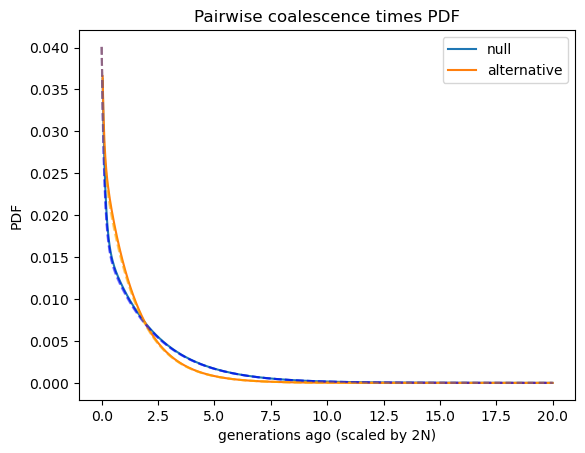

In [57]:
# Plot single locus curves
time_bins = two_locus_models[0][0].joint_pdf[1][1:]
plt.plot(time_bins, single_locus_models[0], label="null")
plt.plot(time_bins, single_locus_models[1], label="alternative")
# Plot marginals from the two locus versus the single locus models 
for null, alt in two_locus_models:
    plt.plot(null.joint_pdf[1], null.get_marginal_pdf(), linestyle='--', alpha=0.1, color='blue')
    plt.plot(alt.joint_pdf[1], alt.get_marginal_pdf(), linestyle='--', alpha=0.1, color='orange')
plt.title("Pairwise coalescence times PDF")
plt.xlabel("generations ago (scaled by 2N)")
plt.ylabel("PDF")
plt.legend()
plt.show()

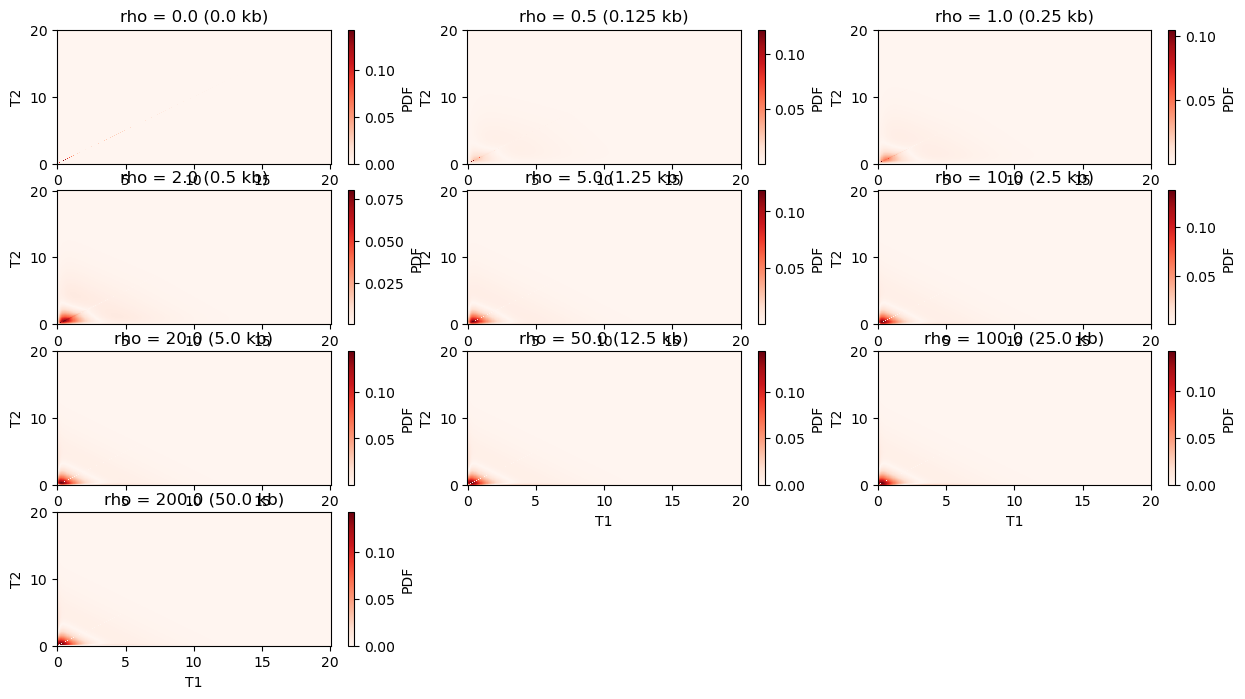

In [58]:
# Plot difference between null and alt heatmaps
fig, axes = plt.subplots(4,3,figsize=(3*5,2*4))
axes_flat = axes.flatten()

for ax in axes_flat:
    ax.set_visible(False)

for i, r in enumerate(recombination_rates):
    time_bins = two_locus_models[i][0].joint_pdf[1]
    pdf_diff = np.abs(two_locus_models[i][0].joint_pdf[0] - two_locus_models[i][1].joint_pdf[0])
    plot_pdf(time_bins, time_bins, pdf_diff, cmap="Reds", kind='heatmap', ax=axes_flat[i])
    axes_flat[i].set_title(f"rho = {4*DEME_SIZES[0]*r} ({r/1e-4} kb)")
    axes_flat[i].set_visible(True)

plt.show()

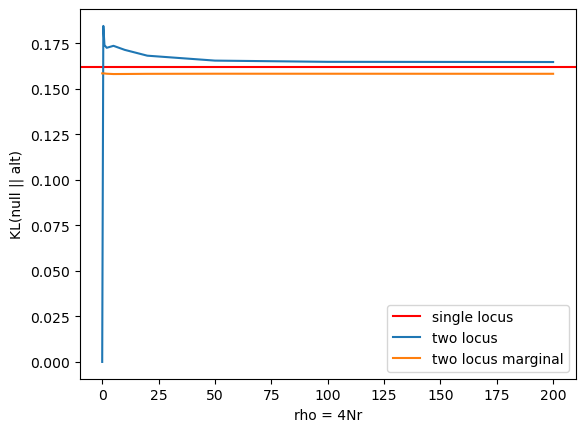

In [59]:
# Plot KL divergence at each recombination distance to compare single vs. two locus

# Define function to compute KL divergence
def KLdivergence(null, alt, time_bins):
    # P log(P/Q)
    # Assume equally spaced time bins 
    dt = time_bins[1] - time_bins[0]
    if np.ndim(null) < 2:
        # The single locus PDFs are calculated by taking the difference between successive bins in the CDF
        # don't need to multiply by dt (already accounted for in each bin)
        # KL divergence between 2 marginal (single locus) distributions is NOT comparable to the KL divergence between two joint distributions
        # Instead compare to the naive joint where the two loci are assumed independent
        # The diagonal has a different interpretation - so ignore the diagonal!
        f0x, f0y = np.meshgrid(null, null, indexing="ij")
        f1x, f1y = np.meshgrid(alt, alt, indexing="ij")
        null = f0x*f0y
        alt = f1x*f1y
        np.fill_diagonal(null, 0)
        np.fill_diagonal(alt, 0)
        # Do not need to condition on T1!=T2 because the joint PDF when assuming both are independent should have zero density on the diagonal
        # Still normalize to sum to 1 so that small fluctuations in sum due to discretization approx. do not have large impacts on the KL divergence
        null_total = null.sum()
        null = null / null_total if null_total > 0 else null
        alt_total = alt.sum()
        alt = alt / alt_total if alt_total > 0 else alt
        # print(null.sum(), alt.sum())
        # compute KL divergence
        ratio = np.divide(null, alt, where=alt!=0, out=np.zeros_like(null))
        logratio = np.log(ratio, where=ratio!=0, out=np.zeros_like(ratio))
        D = null * logratio
    else:
        # Exclude the diagonal! - when recomb=0, it matches the marginal and everywhere else is 0, when recomb=0.5 it is zero
        grid = np.full(null.shape, dt*dt)
        np.fill_diagonal(grid, 0) # exclude diagonal
        null = null * grid
        alt = alt * grid
        # normalize to condition on P(T1,T2 | T1!=T2)
        null_total = null.sum()
        null = null / null_total if null_total > 0 else null
        alt_total = alt.sum()
        alt = alt / alt_total if alt_total > 0 else alt
        # print(null.sum(), alt.sum())
        # compute KL divergence
        ratio = np.divide(null, alt, where=alt!=0, out=np.zeros_like(null))
        logratio = np.log(ratio, where=ratio!=0, out=np.zeros_like(ratio))
        D = null * logratio
    return D.sum()

time_bins = two_locus_models[0][0].joint_pdf[1] 

single_locus_KL = KLdivergence(single_locus_models[0], single_locus_models[1], time_bins)

two_locus_marginal_KL = [
    KLdivergence(null.get_marginal_pdf(), alt.get_marginal_pdf(), time_bins) for null,alt in two_locus_models
]

two_locus_KL = [
    KLdivergence(null.joint_pdf[0], alt.joint_pdf[0], time_bins) for null,alt in two_locus_models
]

plt.axhline(y=single_locus_KL, color='red', label='single locus')
plt.plot(rho, two_locus_KL, label="two locus")
plt.plot(rho, two_locus_marginal_KL, label="two locus marginal")
plt.xlabel("rho = 4Nr")
plt.ylabel("KL(null || alt)")
plt.legend()
# plt.ylim(0.25, 0.4)
plt.show()